In [1]:
from fourier_paper_reproduction_2023_09_28 import default_config, output_dir
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from misc_utils import read_jsonl_to_df, keep_serializable

from itertools import product
from pathlib import Path

import fire
import jsonlines
import numpy as np
from loguru import logger

from fourier_paper_reproduction import (
    accuracy,
    get_ipr,
    how_many_terms_to_achieve,
    how_many_terms_to_achieve_relative_weight,
    rel_fourier_weight_in_largest_terms,
    sign_overlap,
)
from fourier_supervised_cleanroom import (
    amplitude_median_bin_signal,
    amplitude_prob_median_bin_signal,
    fit_fourier_series,
    ground_state_signal,
    sign_signal,
)
from fourier_paper_reproduction_2023_09_28 import get_config
from fourier_supervised_cleanroom_2023_09_27 import get_lattice

# from heisenberg_hamiltonians import HeisenbergJ1J2
from spin_lattices import (
    KagomeLattice,
    SquareLattice,
    TriangularLattice,
    SpinLattice,
    SquareLatticeNoDiag,
)
from misc_utils import column_to as to

from fourier_paper_reproduction import (
    accuracy,
    get_ipr,
    how_many_terms_to_achieve,
    how_many_terms_to_achieve_relative_weight,
    rel_fourier_weight_in_largest_terms,
    sign_overlap,
    visualize_coeffs,
)

In [2]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
    .assign(
        lattice_id=lambda df: df["lattice"],
        lattice=lambda df: df.lattice.str.replace(r"Lattice.+", "", regex=True),
    )
)

/tmp/nix-shell.cxiv0k/ipykernel_679970/13901051.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


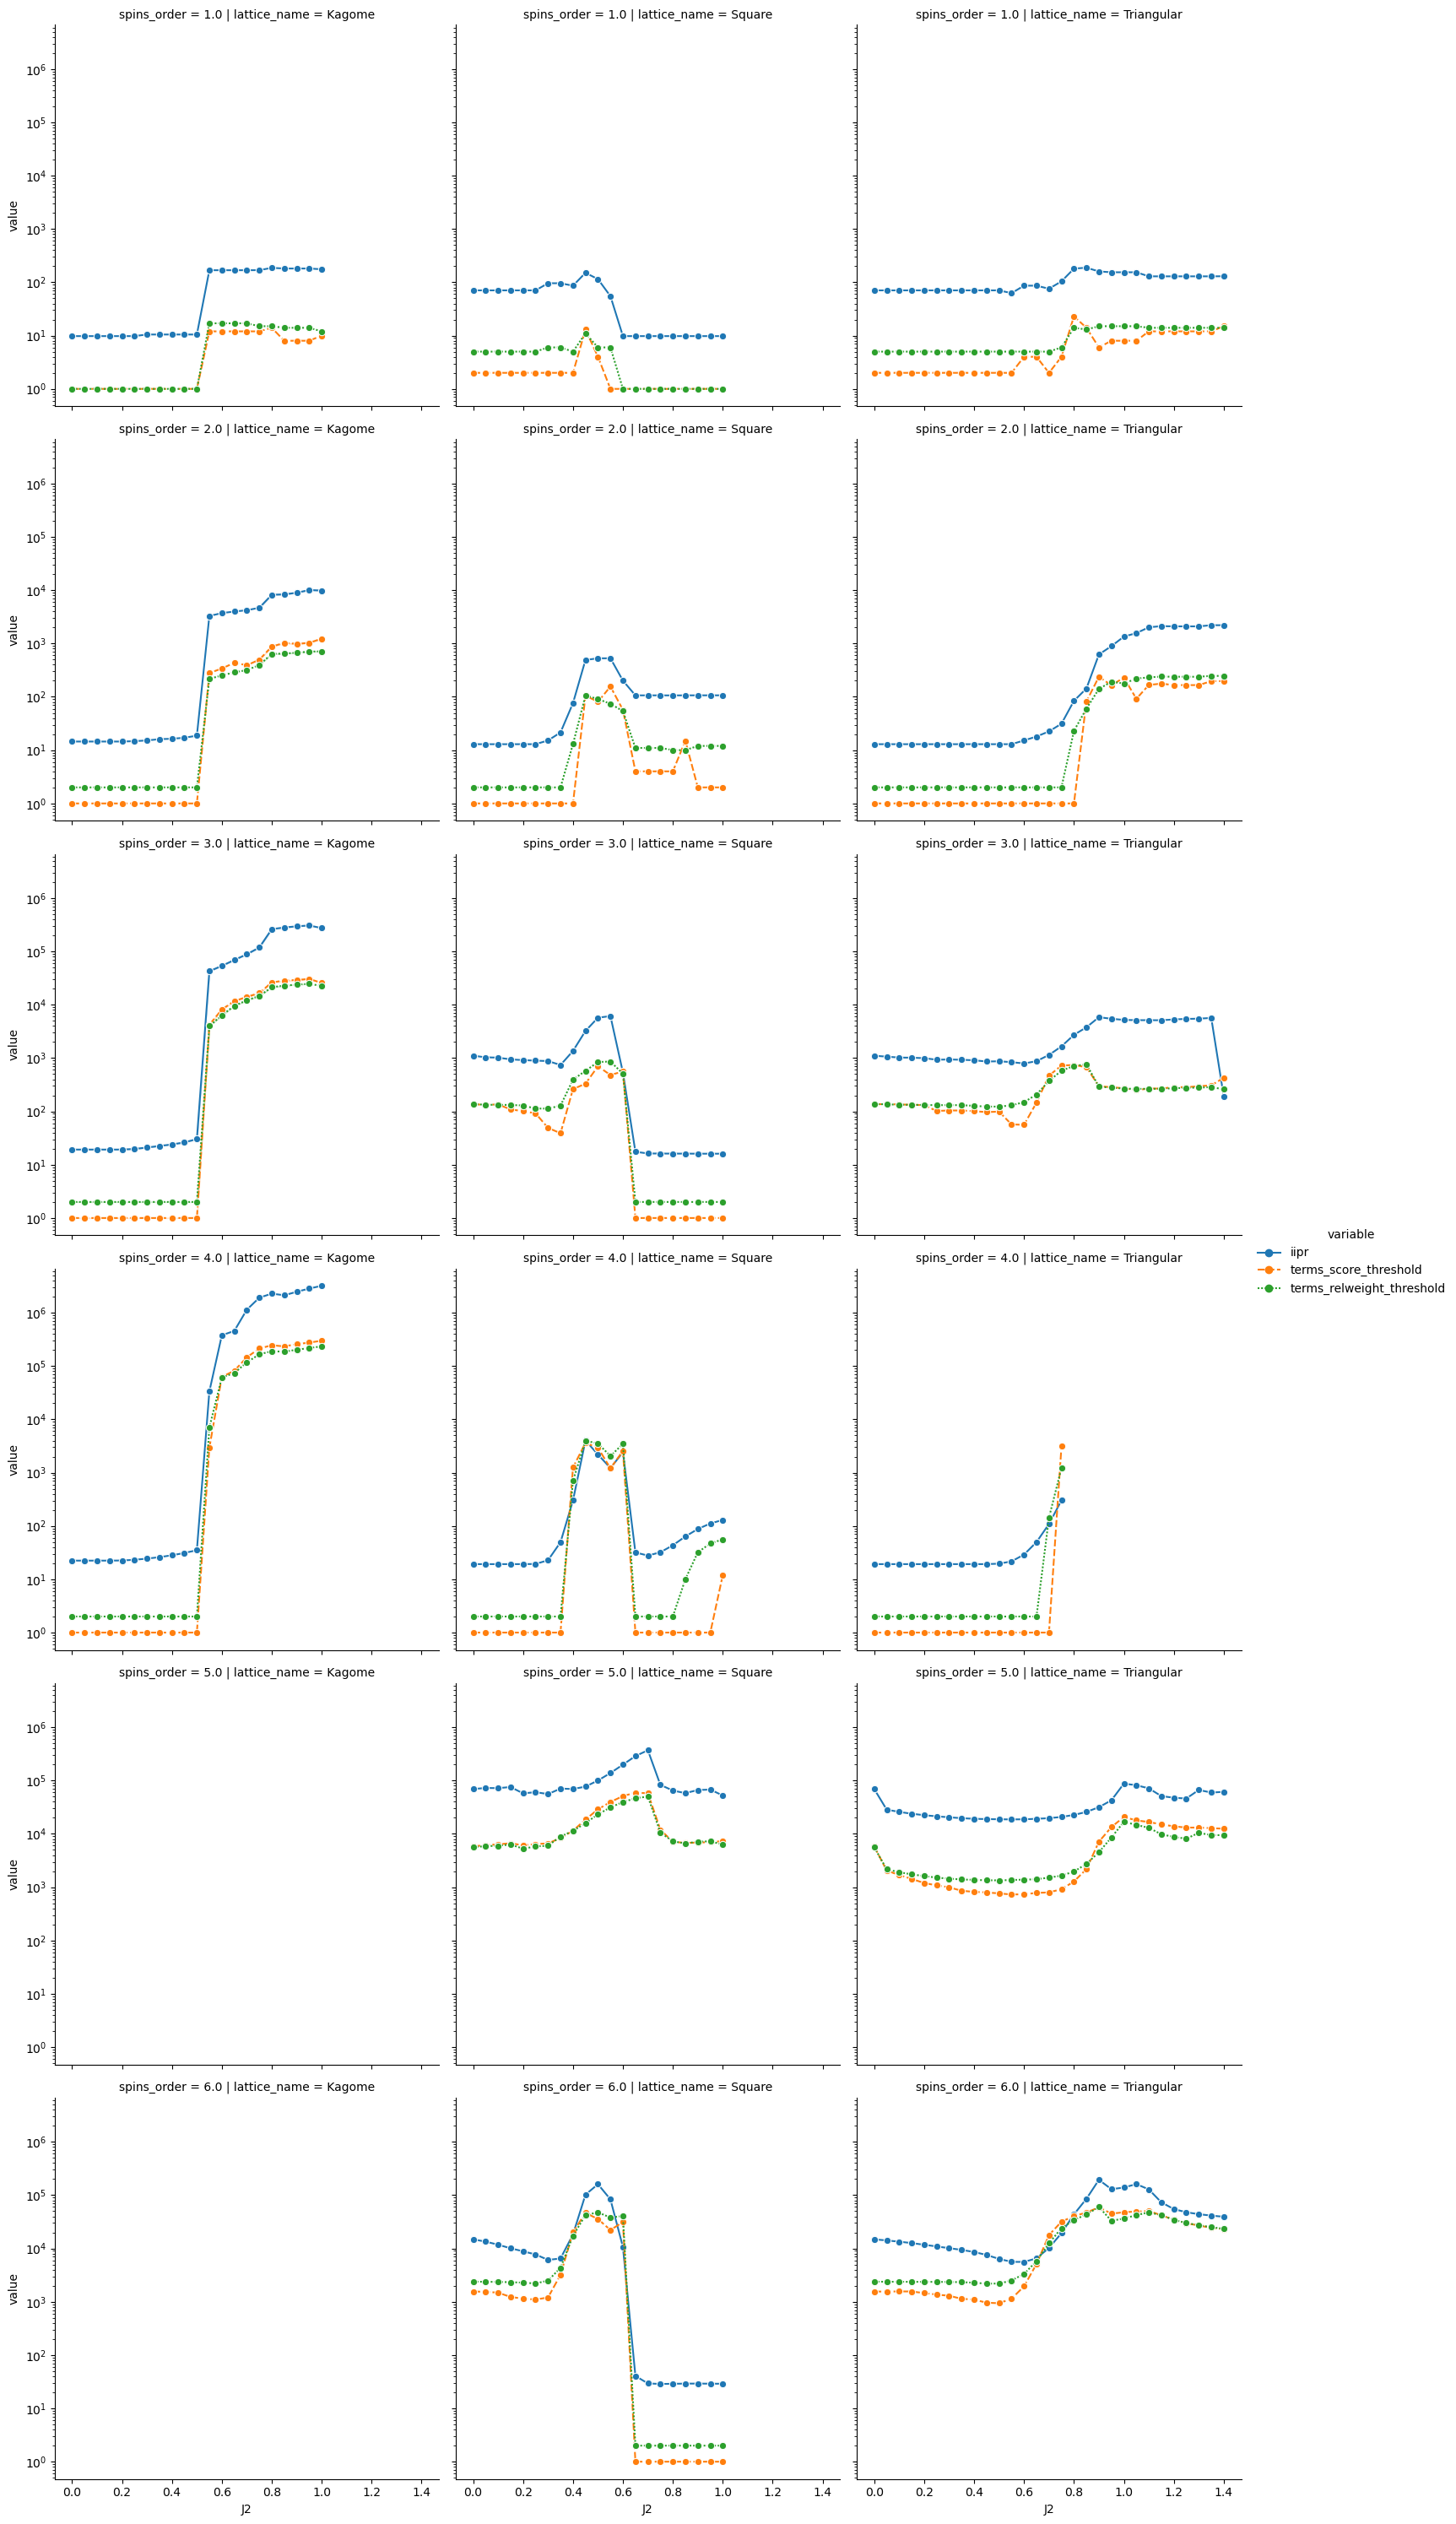

In [4]:
sns.relplot(
    df.query('scorer == "accuracy" and signal == "sign_signal"')
    .melt(
        id_vars=["J2", "lattice", "n_spins", "threshold", "iipr"],
        value_vars=["terms_score_threshold", "terms_relweight_threshold"],
    )
    .query(
        '(threshold == 0.8 and variable == "terms_score_threshold") '
        'or (threshold == 0.2 and variable == "terms_relweight_threshold")'
    )
    .drop(columns=["threshold"])
    .pivot_table(
        values="value", index=["J2", "lattice", "n_spins", "iipr"], columns="variable"
    )
    .reset_index()
    .melt(
        id_vars=["J2", "lattice", "n_spins"],
        value_vars=["iipr", "terms_score_threshold", "terms_relweight_threshold"],
    )
    .sort_values("n_spins")
    .assign(
        lattice_name=lambda df: df.lattice.str.replace(
            r"Lattice.+", "Lattice", regex=True
        ),
        spins_order=lambda df: df.groupby("lattice_name")["n_spins"].transform(
            lambda x: x.rank(method="dense")
        ),
    ),
    x="J2",
    y="value",
    hue="variable",
    col="lattice_name",
    row="spins_order",
    kind="line",
    markers=["o"],
    style="variable",
).set(yscale="log")

/tmp/nix-shell.uH4Kom/ipykernel_2924992/3426510079.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


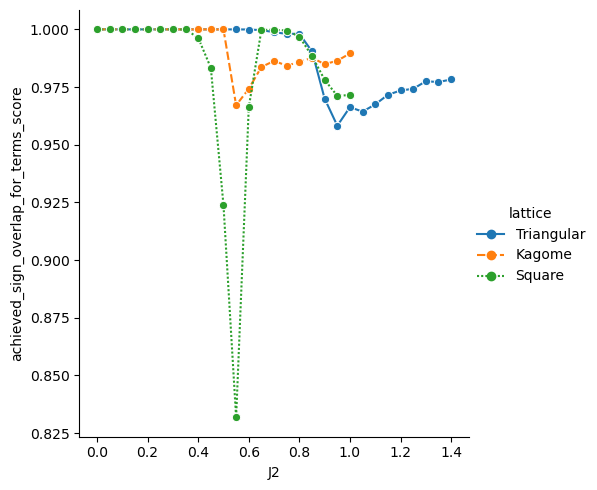

In [3]:
sns.relplot(
    df.query(
        'scorer == "accuracy" and signal == "sign_signal"'
        "and threshold == 0.8 and n_spins == 24"
    ),
    x="J2",
    y="achieved_sign_overlap_for_terms_score",
    hue="lattice",
    kind="line",
    style="lattice",
    markers=["o"],
)

In [ ]:
sns.relplot(
    df.query('scorer == "accuracy" and signal == "sign_signal"')
    .melt(
        id_vars=["J2", "lattice", "n_spins", "threshold", "iipr"],
        value_vars=["terms_score_threshold", "terms_relweight_threshold"],
    )
    .query(
        '(threshold == 0.8 and variable == "terms_score_threshold") '
        'or (threshold == 0.2 and variable == "terms_relweight_threshold")'
    )
    .drop(columns=["threshold"])
    .pivot_table(
        values="value", index=["J2", "lattice", "n_spins", "iipr"], columns="variable"
    )
    .reset_index()
    .rename(
        columns={
            "iipr": "participation ratio",
            "terms_score_threshold": "prediction quality",
            "terms_relweight_threshold": "weight",
        }
    )
    .rename(columns={"lattice_name": "lattice", "J2": "$J_2/J_1$"})
    .rename(columns={"prediction quality": "Boolean complexity"})
    .sort_values("n_spins")
    .query("n_spins == 24"),
    x="$J_2/J_1$",
    y="complexity",
    hue="complexity measure",
    col="lattice",
    kind="line",
    # markers=["."],
    style="complexity measure",
    facet_kws={"sharex": False},
    height=2.8,
    col_order=["Square", "Triangular", "Kagome"]
    # legend=False,
).set(yscale="log")
# plt.savefig("fig/complexity-measures.pdf", bbox_inches="tight")

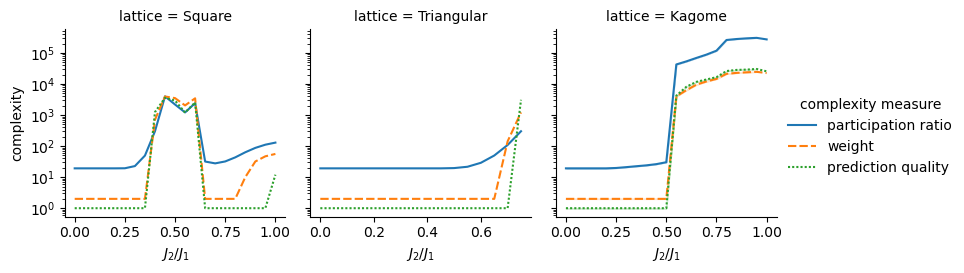

In [5]:
sns.relplot(
    df.query('scorer == "accuracy" and signal == "sign_signal"')
    .melt(
        id_vars=["J2", "lattice", "n_spins", "threshold", "iipr"],
        value_vars=["terms_score_threshold", "terms_relweight_threshold"],
    )
    .query(
        '(threshold == 0.8 and variable == "terms_score_threshold") '
        'or (threshold == 0.2 and variable == "terms_relweight_threshold")'
    )
    .drop(columns=["threshold"])
    .pivot_table(
        values="value", index=["J2", "lattice", "n_spins", "iipr"], columns="variable"
    )
    .reset_index()
    .rename(
        columns={
            "iipr": "participation ratio",
            "terms_score_threshold": "prediction quality",
            "terms_relweight_threshold": "weight",
        }
    )
    .melt(
        id_vars=["J2", "lattice", "n_spins"],
        value_vars=["participation ratio", "prediction quality", "weight"],
        value_name="complexity",
        var_name="complexity measure",
    )
    .rename(columns={"lattice_name": "lattice", "J2": "$J_2/J_1$"})
    .sort_values("n_spins")
    .query("n_spins == 24"),
    x="$J_2/J_1$",
    y="complexity",
    hue="complexity measure",
    col="lattice",
    kind="line",
    # markers=["."],
    style="complexity measure",
    facet_kws={"sharex": False},
    height=2.8,
    col_order=["Square", "Triangular", "Kagome"]
    # legend=False,
).set(yscale="log")
plt.savefig("fig/complexity-measures.pdf", bbox_inches="tight")

In [20]:
df.query('lattice == "Triangular" and n_spins == 24')["J2"].unique()[10]

0.49999999999999994

In [23]:
frustrated_J2s = pd.DataFrame(
    [
        {"lattice": "Kagome", "J2": 1},
        {"lattice": "Square", "J2": 0.5},
        {"lattice": "Triangular", "J2": 1.4},
    ]
)

non_frustrated_J2s = pd.DataFrame(
    [
        {"lattice": "Kagome", "J2": 0.4},
        {"lattice": "Square", "J2": 0.2},
        {"lattice": "Triangular", "J2": 0.49999999999999994},
    ]
)

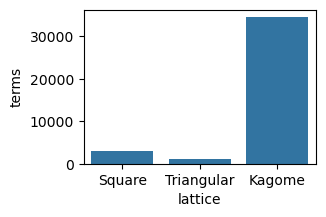

In [13]:
fig, ax = plt.subplots(figsize=(3, 2))
sns.barplot(
    df.merge(frustrated_J2s, how="right", on=["lattice", "J2"])
    .query(
        "threshold == 0.8 "
        "and n_spins == 24 "
        " and signal=='sign_signal'"
        "and scorer=='accuracy'"
    )
    .rename(columns={"terms_score_threshold": "terms"}),
    x="lattice",
    y="terms",
    order=["Square", "Triangular", "Kagome"],
    color="C0",
    ax=ax,
)
plt.savefig("fig/complexity-of-different-lattices.pdf", bbox_inches="tight")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


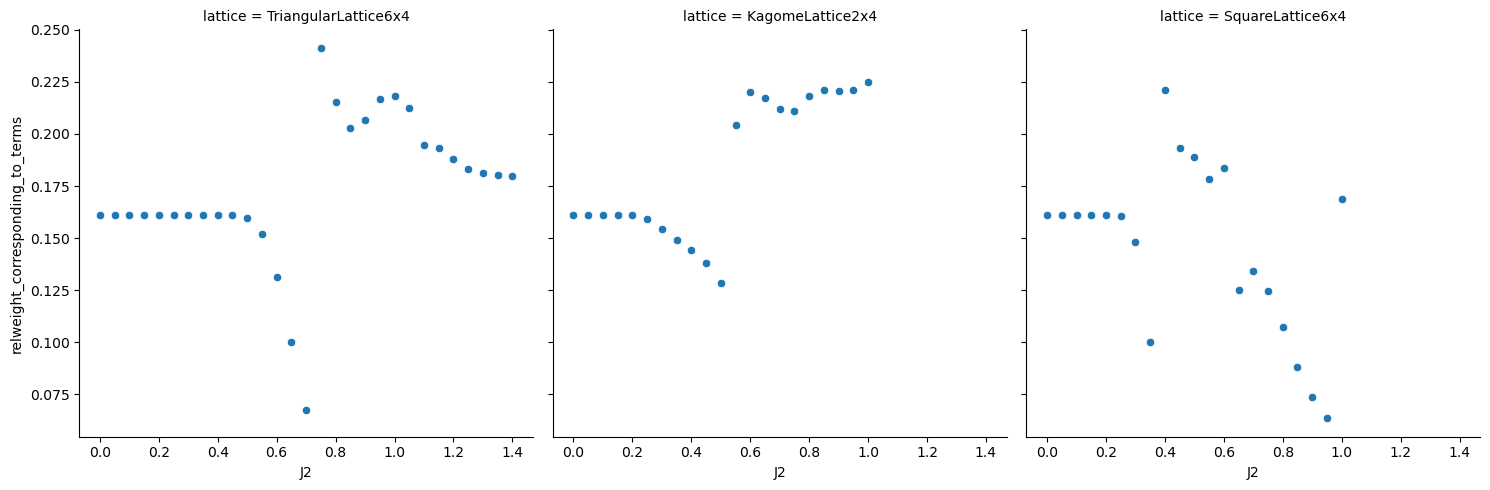

In [29]:
sns.relplot(
    df.query(
        'scorer == "accuracy" and signal == "sign_signal" and threshold == 0.8 and n_spins == 24'
    ),
    x="J2",
    y="relweight_corresponding_to_terms",
    col="lattice",
)

<Axes: xlabel='relweight_corresponding_to_terms', ylabel='Count'>

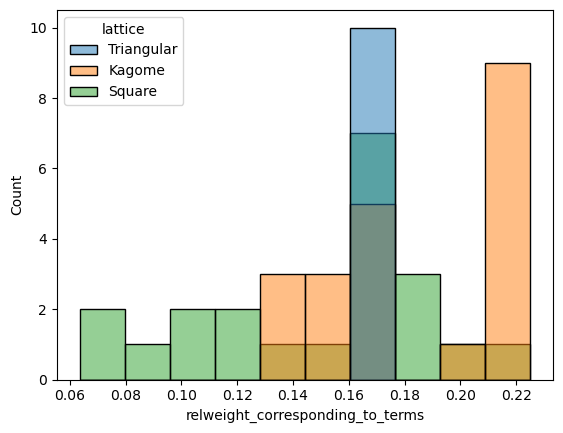

In [50]:
sns.histplot(
    df.query(
        'scorer == "accuracy" and signal == "sign_signal" and threshold == 0.8 and n_spins == 24'
    ),
    x="relweight_corresponding_to_terms",
    hue="lattice",
)

In [7]:
df['lattice']

0        Triangular
1        Triangular
2        Triangular
3        Triangular
4        Triangular
            ...    
25625        Square
25626        Square
25627        Square
25628        Square
25629        Square
Name: lattice, Length: 25630, dtype: object

/tmp/nix-shell.0cm8Ru/ipykernel_1905508/1777025624.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


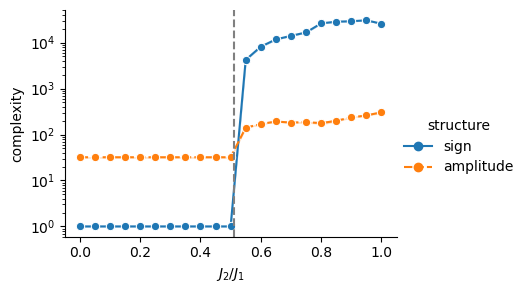

In [37]:
g = sns.relplot(
    df.query(
        'scorer == "accuracy" and '
        "threshold == 0.8 and "
        '(signal == "sign_signal" or signal == "amplitude_median_bin_signal")'
    )
    .query("n_spins == 24")
    .query('lattice == "Kagome"')
    .replace(
        {"signal": {"amplitude_median_bin_signal": "amplitude", "sign_signal": "sign"}}
    ).rename(columns={"terms_score_threshold": "complexity", "signal": "structure", "J2": "$J_2/J_1$"}),
    x="$J_2/J_1$",
    y="complexity",
    hue="structure",
    #    col="lattice",
    #    col_wrap=3,
    kind="line",
    markers=["o"],
    style="structure",
    height=3,
    aspect=1.5,
).set(yscale="log")
g.ax.axvline(0.51, color="gray", linestyle="--")
plt.savefig("fig/signs_vs_amplitude_kagome.png", dpi=300)

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


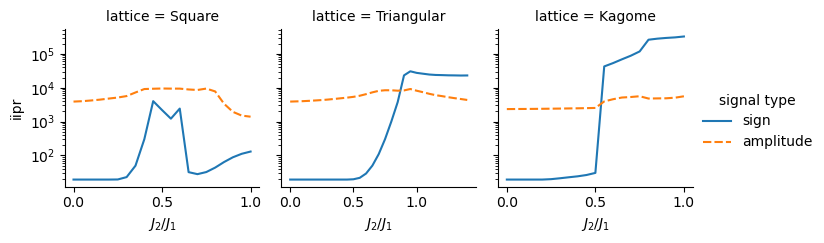

In [25]:
sns.relplot(
    df.query(
        'scorer == "accuracy"  '
        "and threshold == 0.8  "
        'and (signal == "sign_signal" or signal == "amplitude_median_bin_signal")'
        "and n_spins == 24"
    )
    .assign(
        signal=lambda df: df["signal"].replace(
            {"sign_signal": "sign", "amplitude_median_bin_signal": "amplitude"}
        )
    )
    .rename(
        columns={
            "signal": "signal type",
            "terms_score_threshold": "terms",
            "J2": "$J_2/J_1$",
        }
    ),
    x="$J_2/J_1$",
    y="iipr",
    hue="signal type",
    col="lattice",
    col_order=["Square", "Triangular", "Kagome"],
    kind="line",
    #    markers=["o"],
    style="signal type",
    height=2.5,
    facet_kws={"sharex": False},
).set(yscale="log")
plt.savefig("fig/signs-vs-amplitudes-complexity.pdf", bbox_inches="tight")

/tmp/nix-shell.0cm8Ru/ipykernel_1905508/819581865.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


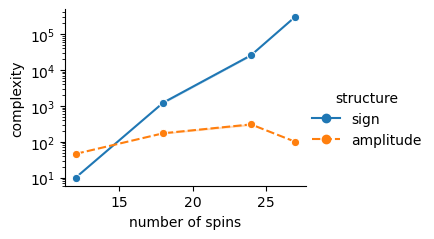

In [35]:
sns.relplot(
    df
    .query(
        'scorer == "accuracy" and threshold == 0.8 '
        'and signal in ["sign_signal", "amplitude_median_bin_signal"] '
        'and lattice == "Kagome" '
        'and J2 == 1.'
    )
    .replace(
        {"signal": {"amplitude_median_bin_signal": "amplitude", "sign_signal": "sign"}}
    )
    .rename(
        columns={
            "lattice": "lat",
            "terms_score_threshold": "complexity",
            "n_spins": "number of spins",
            "signal": "structure",
        }
    ),
    x="number of spins",
    y="complexity",
    hue="structure",
    kind="line",
    style="structure",
    markers=["o"],
    height=2.5,
    aspect=1.5,
    col_order=["Square", "Triangular", "Kagome"],
).set(yscale="log")
plt.savefig("fig/complexity-scaling_kagome.png", bbox_inches="tight", dpi=300)

/tmp/nix-shell.0cm8Ru/ipykernel_1905508/954749489.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


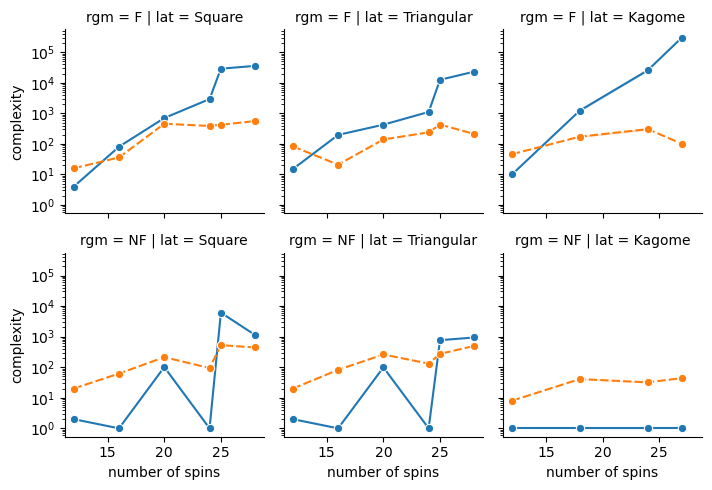

In [24]:
sns.relplot(
    pd.concat(
        [
            df.merge(frustrated_J2s, how="right", on=["lattice", "J2"]).assign(rgm="F"),
            df.merge(non_frustrated_J2s, how="right", on=["lattice", "J2"]).assign(
                rgm="NF"
            ),
        ]
    )
    .query(
        'scorer == "accuracy" and threshold == 0.8 '
        'and signal in ["sign_signal", "amplitude_median_bin_signal"]'
    )
    .rename(
        columns={
            "lattice": "lat",
            "terms_score_threshold": "complexity",
            "n_spins": "number of spins",
        }
    ),
    x="number of spins",
    y="complexity",
    hue="signal",
    col="lat",
    row="rgm",
    kind="line",
    style="signal",
    markers=["o"],
    height=2.5,
    legend=False,
    col_order=["Square", "Triangular", "Kagome"],
).set(yscale="log")
plt.savefig("fig/complexity-scaling.pdf", bbox_inches="tight")

/tmp/nix-shell.5n1UNd/ipykernel_586863/2442400427.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


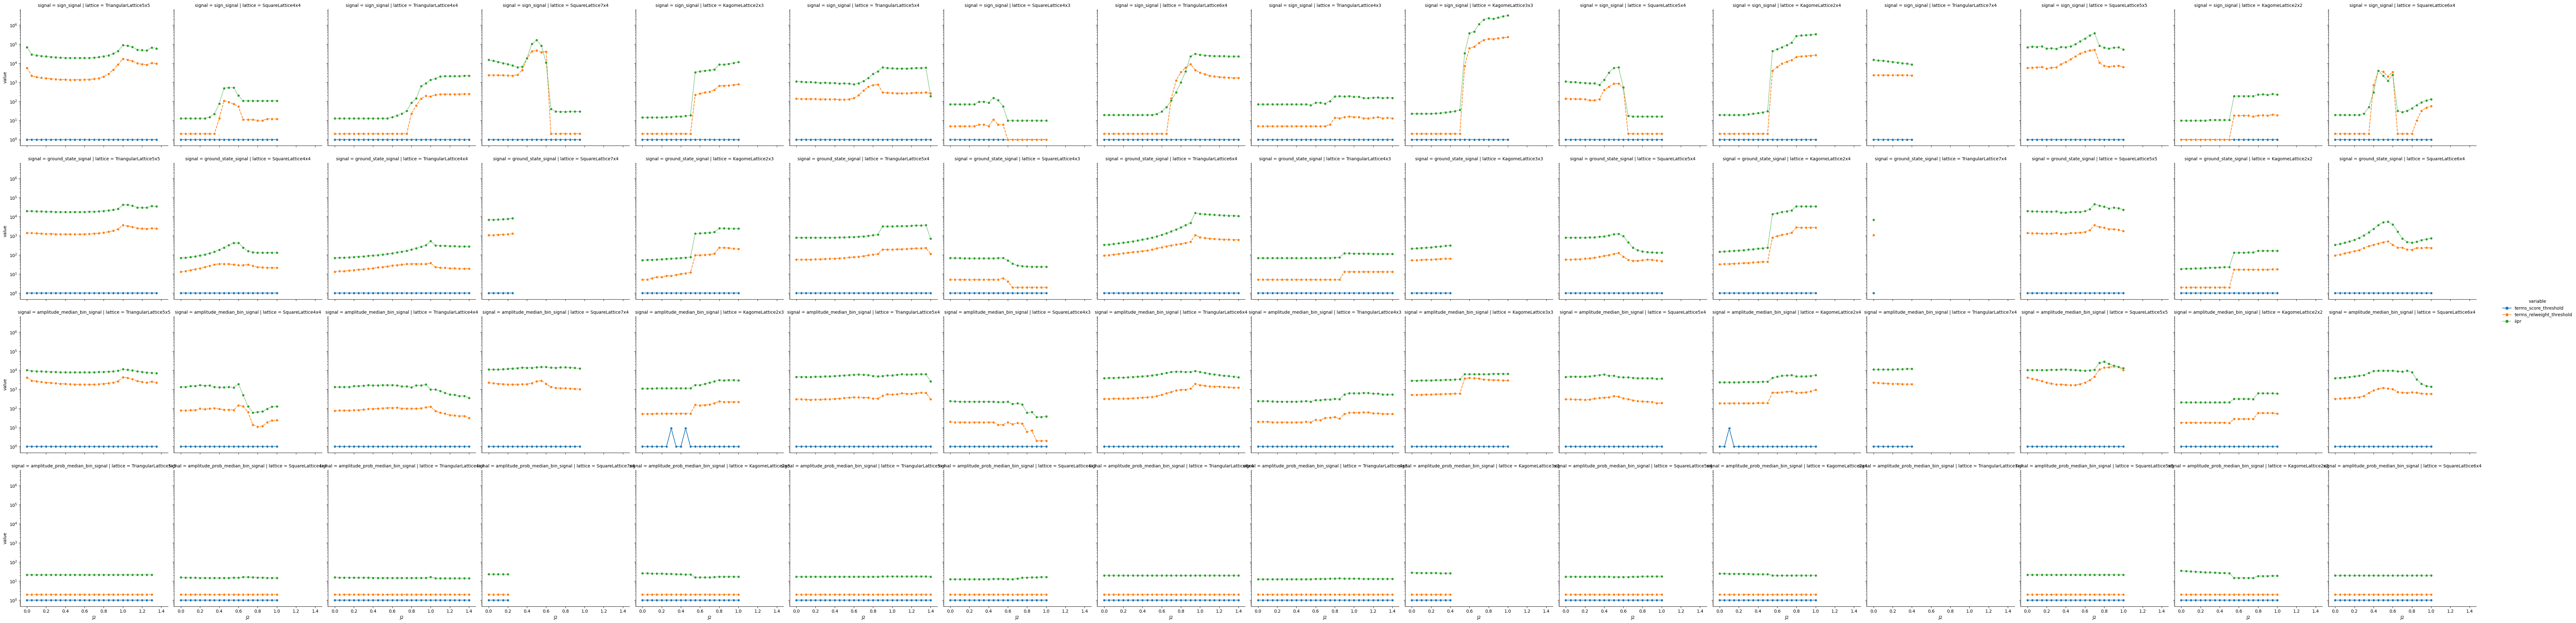

In [6]:
# sns.relplot(
#     df.query('threshold == 0.2 and scorer == "accuracy"').melt(
#         id_vars=["J2", "lattice", "n_spins", "threshold", "scorer", "signal"],
#         value_vars=["terms_score_threshold", "terms_relweight_threshold", "iipr"],
#     ),
#     x="J2",
#     y="value",
#     hue="variable",
#     col="lattice",
#     row="signal",
#     kind="line",
#     markers=["o"],
#     style="variable",
# ).set(yscale="log")

In [6]:
special_configs = pd.concat(
    [
        frustrated_J2s,
        non_frustrated_J2s,
        pd.DataFrame(
            [
                {"lattice": "Square", "J2": 0.8},
                {"lattice": "Triangular", "J2": 1.2999999999999998},
            ]
        ),
    ],
    ignore_index=True,
)

In [7]:
signal_names = {
    sign_signal: "sign",
    amplitude_median_bin_signal: "binarized amplitude",
}

2023-10-17 14:00:28.322 | DEBUG    | spin_lattices:make_fourier_basis:134 - Cached fourier_basis not found, building...


2023-10-17 14:00:38.799 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-10-17 14:00:38.804 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 0 elements
2023-10-17 14:00:38.805 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-10-17 14:00:38.894 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 2704156
2023-10-17 14:00:38.906 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2-1.0-0.4-False-None-1.pickle
2023-10-17 14:00:38.936 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -40.7607708401


amplitude_median_bin_signal


2023-10-17 14:00:39.707 | DEBUG    | spin_lattices:get_fourier_basis_data:171 - Using cached fourier_repr


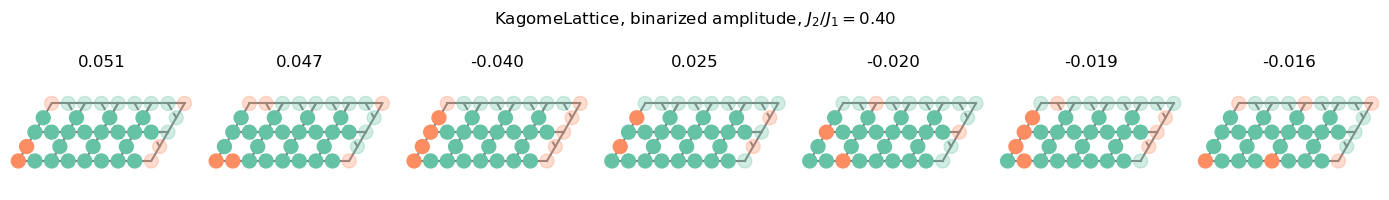

2023-10-17 14:00:42.863 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-10-17 14:00:42.864 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 0 elements
2023-10-17 14:00:42.865 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-10-17 14:00:42.867 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 2704156
2023-10-17 14:00:42.877 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2-1.0-1.0-False-None-1.pickle
2023-10-17 14:00:42.890 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -43.0395889923
2023-10-17 14:00:43.822 | DEBUG    | spin_lattices:get_fourier_basis_data:171 - Using cached fourier_repr


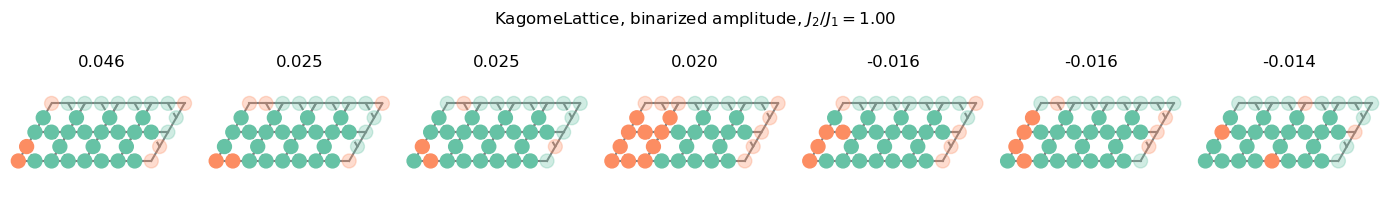

2023-10-17 14:00:47.779 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-10-17 14:00:47.786 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 0 elements
2023-10-17 14:00:47.787 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-10-17 14:00:47.788 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 2704156
2023-10-17 14:00:47.805 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2-1.0-0.4-False-None-1.pickle
2023-10-17 14:00:47.840 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -40.7607708401


sign_signal


2023-10-17 14:00:48.783 | DEBUG    | spin_lattices:get_fourier_basis_data:171 - Using cached fourier_repr


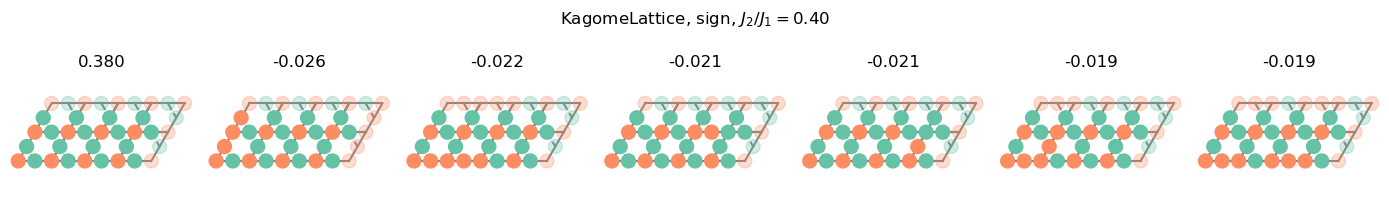

2023-10-17 14:00:51.994 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-10-17 14:00:51.996 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 0 elements
2023-10-17 14:00:51.997 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-10-17 14:00:51.999 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 2704156
2023-10-17 14:00:52.011 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2-1.0-1.0-False-None-1.pickle
2023-10-17 14:00:52.025 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -43.0395889923
2023-10-17 14:00:52.756 | DEBUG    | spin_lattices:get_fourier_basis_data:171 - Using cached fourier_repr


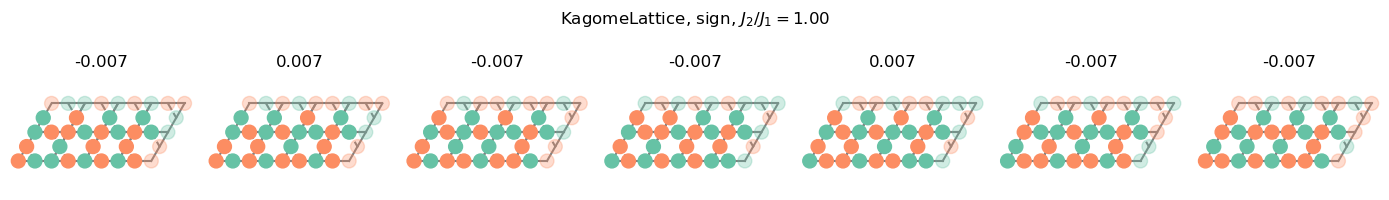

In [10]:
(Path("fig") / "expansions").mkdir(exist_ok=True)

for task_id in [19]:  # 13, 7,
    config = get_config(task_id)
    lattice = get_lattice(config["lattice"])
    # if lattice.__class__.__name__ == "KagomeLattice":
    #     swap_axes = True
    # else:
    #     swap_axes = False
    swap_axes = False
    fourier_basis_data = lattice.get_fourier_basis_data()
    for signal in [amplitude_median_bin_signal, sign_signal]:
        print(signal.__name__)
        for J2 in config["J2s"]:
            if (
                special_configs.query(
                    'lattice == @lattice.__class__.__name__.replace("Lattice", "") and J2 == @J2'
                ).shape[0]
                == 0
            ):
                continue
            system = HeisenbergJ1J2(lattice, J2=J2, use_symmetries=False)
            system.get_eigenstates(1)
            signal_fn = signal(system)
            expansion = fit_fourier_series(
                system.canonical_basis.states, signal_fn, n_bits=system.number_spins
            )
            fig = visualize_coeffs(
                expansion,
                7,
                lattice,
                show_numbers=False,
                swap_axes=swap_axes,
                size_scale=2,
            )
            fig.suptitle(
                f"{lattice.__class__.__name__}, "
                f"{signal_names[signal]}, $J_2/J_1={J2:.2f}$"
            )
            plt.tight_layout()
            plt.show(fig)
            filename = (
                f"expansion-{lattice.get_cache_id()}-{signal.__name__}-{J2:.2f}.pdf"
            )
            fig.savefig(
                str(Path("fig/expansions") / filename),
                bbox_inches="tight",
            )
            if (
                special_configs.query(
                    'lattice == @lattice.__class__.__name__.replace("Lattice", "") and J2 == @J2'
                ).shape[0]
                > 0
            ):
                fig.savefig(
                    str(Path("fig") / filename),
                    bbox_inches="tight",
                )

            plt.close(fig)

In [3]:
lattice = KagomeLattice(4, 2)
system = HeisenbergJ1J2(lattice, J2=1, use_symmetries=False)
system.get_eigenstates(1)
signal_fn = sign_signal(system, tol=1e-14)
expansion = fit_fourier_series(
    system.canonical_basis.states, signal_fn, n_bits=system.number_spins
)


2024-01-23 16:54:32.246 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-01-23 16:54:32.248 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-23 16:54:32.249 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-23 16:54:32.250 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis


2024-01-23 16:54:32.329 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 2704156
2024-01-23 16:54:32.343 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2-1.0-1.0-False-None-1.pickle
2024-01-23 16:54:32.379 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -43.0395889923


[-0.00731068 -0.00731068 -0.00731068  0.00731068 -0.00731068  0.00731068
 -0.00731068  0.00731068 -0.00731068  0.00731068 -0.00731068  0.00731068
  0.00731068  0.00731068  0.00731068  0.00731068]


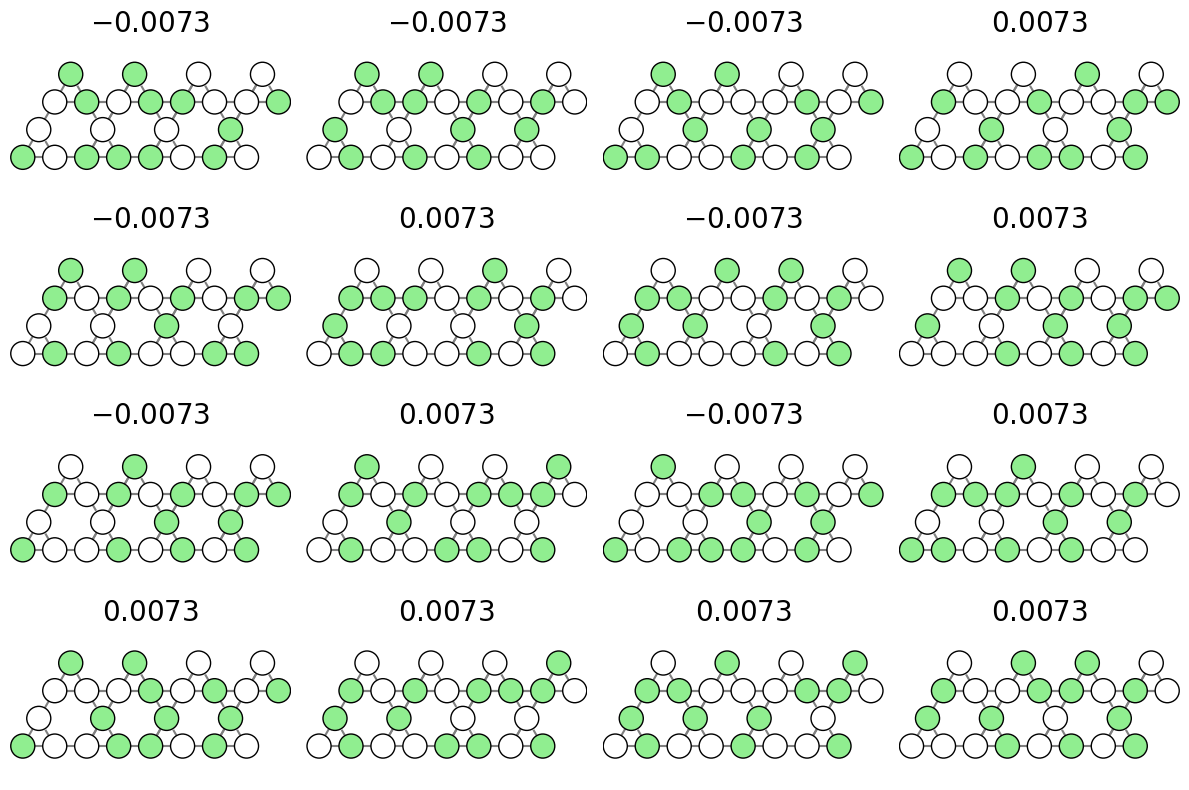

In [4]:
fig = visualize_coeffs(
    expansion,
    16,
    lattice,
    up_to_symmetry=False,
    show_numbers=False,
    swap_axes=False,
    size_scale=None,
    size_scale_x=3,
    size_scale_y=2,
    col_wrap=4,
    show_boundary_conditions=False,
    color_map={0: "white", 1: "lightgreen"},
    scatter_kws=dict(s=300, edgecolors="black", legend=False),
    title_fontsize=20,
)

fig.tight_layout()
fig.savefig("fig/kagome-isotropic-expansion.png", dpi=300)

In [5]:
(expansion != 0).sum() - 16

7295664

In [6]:
(expansion != 0).mean()

0.4348564147949219

2024-01-20 22:58:30.159 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=16
2024-01-20 22:58:30.160 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-20 22:58:30.162 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-20 22:58:30.164 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-20 22:58:30.174 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 12870
2024-01-20 22:58:30.183 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLatticeNoDiag4x4-1.0-1.0-False-None-1.pickle
2024-01-20 22:58:30.184 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -44.9139328337


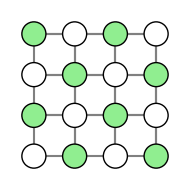

In [32]:
lattice = SquareLatticeNoDiag(4, 4)
system = HeisenbergJ1J2(lattice, J2=1, use_symmetries=False, spin_inversion=None)
system.get_eigenstates(1)
signal_fn = sign_signal(system)
expansion = fit_fourier_series(
    system.canonical_basis.states, signal_fn, n_bits=system.number_spins
)

fig = lattice.plot_subsets(
    subsets=[np.uint64(np.argmax(np.abs(expansion)))],
    titles=[""],
    size_scale=2,
    show_boundary_conditions=False,
    color_map={0: "white", 1: "lightgreen"},
    scatter_kws=dict(s=300, edgecolors="black", legend=False),
    show_numbers=False,
)
fig.axes[0].margins(0.2)
fig.tight_layout()
fig.savefig("fig/square-marshall-sign-rule.png", dpi=300)
# fig = visualize_coeffs(
#     expansion,
#     1,
#     lattice,
#     show_numbers=False,
#     swap_axes=False,
#     size_scale=2,
#     col_wrap=4,
#     show_boundary_conditions=False,
#     color_map={0: "white", 1: "C4"},
#     scatter_kws=dict(s=300, edgecolors="black"),
# )

# fig.tight_layout()

2024-01-22 19:22:14.281 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-01-22 19:22:14.282 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-22 19:22:14.283 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-22 19:22:14.284 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-22 19:22:14.334 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 2704156
2024-01-22 19:22:14.349 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2_isotropic-1.0-1.0-False-None-1.pickle
2024-01-22 19:22:14.380 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -43.0395889923


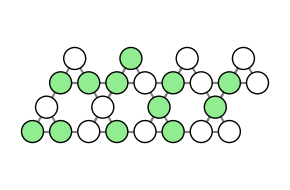

In [8]:
lattice = KagomeLattice(4, 2, isotropic=True)
system = HeisenbergJ1J2(lattice, use_symmetries=False, spin_inversion=None)
system.get_eigenstates(1)
signal_fn = sign_signal(system, tol=1e-14)
expansion = fit_fourier_series(
    system.canonical_basis.states, signal_fn, n_bits=system.number_spins
)

fig = lattice.plot_subsets(
    subsets=[np.uint64(np.argmax(np.abs(expansion)))],
    titles=[""],
    size_scale=None,
    size_scale_x=3,
    size_scale_y=2,
    show_boundary_conditions=False,
    color_map={0: "white", 1: "lightgreen"},
    scatter_kws=dict(s=250, edgecolors="black", legend=False),
    show_numbers=False,
)
fig.axes[0].margins(0.1)
fig.tight_layout()
fig.savefig("fig/kagome-lattice-subset.png", dpi=300)
# fig = visualize_coeffs(
#     expansion,
#     1,
#     lattice,
#     show_numbers=False,
#     swap_axes=False,
#     size_scale=2,
#     col_wrap=4,
#     show_boundary_conditions=False,
#     color_map={0: "white", 1: "C4"},
#     scatter_kws=dict(s=300, edgecolors="black"),
# )

In [4]:
lattice = KagomeLattice(4, 2)
system = HeisenbergJ1J2(lattice, J2=1, use_symmetries=False)
system.get_eigenstates(1)
signal_fn = sign_signal(system)
expansion = fit_fourier_series(
    system.canonical_basis.states, signal_fn, n_bits=system.number_spins
)
np.argmax(expansion)

2024-01-22 19:20:51.532 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-01-22 19:20:51.534 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-22 19:20:51.536 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-22 19:20:51.537 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-22 19:20:51.603 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 2704156
2024-01-22 19:20:51.614 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2-1.0-1.0-False-None-1.pickle
2024-01-22 19:20:51.638 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -43.0395889923


5627966

<Axes: xlabel='emb_x', ylabel='emb_y'>

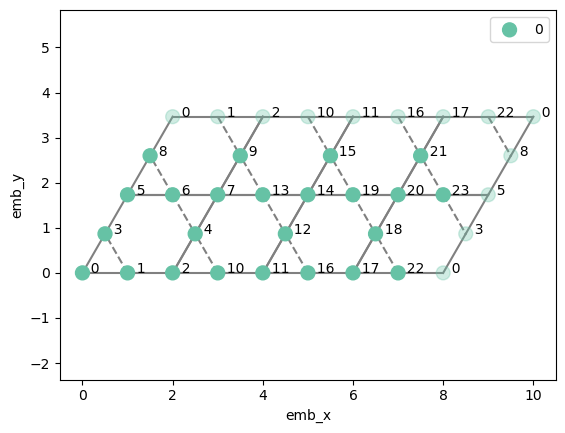

In [45]:
lattice.plot()

In [22]:
system.ground_state

array([ 1.41819785e-18, -1.22464750e-07, -2.31909806e-06, ...,
       -2.31909806e-06, -1.22464750e-07,  3.01904049e-18])

<Axes: xlabel='emb_x', ylabel='emb_y'>

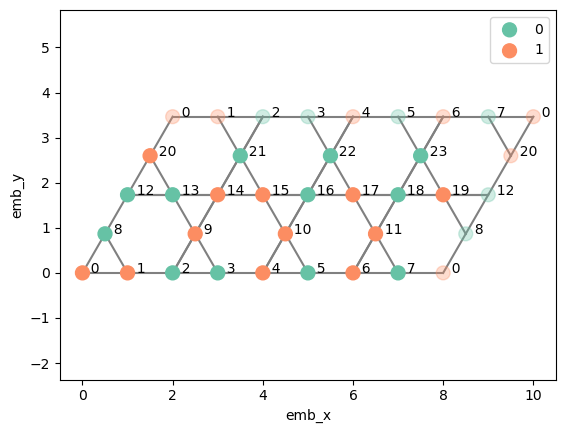

In [18]:
lattice.plot(spins=1756755)

In [10]:
lattice_isotropic = KagomeLattice(4, 2, isotropic=True)
system_isotropic = HeisenbergJ1J2(lattice_isotropic, use_symmetries=False, spin_inversion=None)
system_isotropic.get_eigenstates(1)
signal_fn_isotropic = sign_signal(system_isotropic, tol=1e-14)
expansion_isotropic = fit_fourier_series(
    system.canonical_basis.states, signal_fn_isotropic, n_bits=system.number_spins
)
np.argmax(expansion_isotropic)

2024-01-22 19:23:14.497 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-01-22 19:23:14.497 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-22 19:23:14.498 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-22 19:23:14.499 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-22 19:23:14.659 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 2704156
2024-01-22 19:23:14.675 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2_isotropic-1.0-1.0-False-None-1.pickle
2024-01-22 19:23:14.689 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -43.0395889923


1398730

In [11]:
lattice_isotropic = KagomeLattice(4, 2, isotropic=True)
system_isotropic = HeisenbergJ1J2(lattice_isotropic, use_symmetries=False, spin_inversion=None)
system_isotropic.get_eigenstates(1)
signal_fn_isotropic = sign_signal(system_isotropic, tol=1e-14)
expansion_isotropic = fit_fourier_series(
    system.canonical_basis.states, signal_fn_isotropic, n_bits=system.number_spins
)
np.argmax(expansion_isotropic)

2024-01-22 19:23:34.731 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-01-22 19:23:34.732 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-22 19:23:34.733 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-22 19:23:34.734 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-22 19:23:34.804 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 2704156
2024-01-22 19:23:34.824 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2_isotropic-1.0-1.0-False-None-1.pickle
2024-01-22 19:23:34.861 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -43.0395889923


1398730

In [61]:
np.max(np.abs(expansion_isotropic))

16.1015625

In [62]:
np.max(np.abs(expansion))

12.669921875

In [43]:
np.max(np.abs(system.ground_state))

0.010367274973947575

In [2]:
threshold = 0.8
outputs = []
for J2 in np.linspace(0, 1, 5):
    lattice = KagomeLattice(2, 4)

    system = HeisenbergJ1J2(lattice, J1=1, J2=J2, use_symmetries=False, spin_inversion=None)
    system.get_eigenstates(1)

    signal_fn = sign_signal(system, tol=1e-14)
    scorer_fn = accuracy(system, signal_fn=signal_fn)

    series_coeffs = fit_fourier_series(
        system.canonical_basis.states, signal_fn=signal_fn, n_bits=system.number_spins
    )

    terms_score = how_many_terms_to_achieve(series_coeffs, threshold, scorer_fn)
    outputs.append(
        {
            "J2": J2,
            "complexity": terms_score,
        }
    )
    

2024-01-23 21:36:42.072 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-01-23 21:36:42.073 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-23 21:36:42.075 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-23 21:36:42.075 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-23 21:36:42.147 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 2704156
2024-01-23 21:36:42.160 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-False-None-1.pickle
2024-01-23 21:36:42.193 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -46.1341392314
2024-01-23 21:36:51.410 | DEBUG    | fourier_paper_reproduction:how_many_terms_to_achieve:39 - Score 1.0 with 8388608 terms is above target score

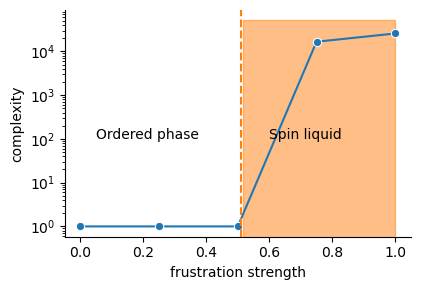

In [4]:
df = pd.DataFrame(outputs)
g = sns.relplot(
    df.rename(columns={"J2": "frustration strength"}),
    x="frustration strength",
    y="complexity",
    kind="line",
    markers=["o"],
    style=1,
    legend=False,
    height=3,
    aspect=1.5,
).set(yscale="log")

# plot vertical line at x=0.51
ax = g.axes[0][0]
ax.axvline(0.51, color="C1", linestyle="dashed")
ax.text(0.05, 100, "Ordered phase")
ax.text(0.6, 100, "Spin liquid")
x = np.linspace(min(df['J2']), max(df['J2']), 100)
ax.fill_between(x, df['complexity'].min() - 100, df['complexity'].max() * 2, where=(x > 0.51), alpha=0.5, color='C1')

plt.savefig("fig/kagome-sign-structure-complexity.png", dpi=300)

In [5]:
df

,J2,complexity
0,0.00,1
1,0.25,1
2,0.50,1
3,0.75,16641
4,1.00,25697


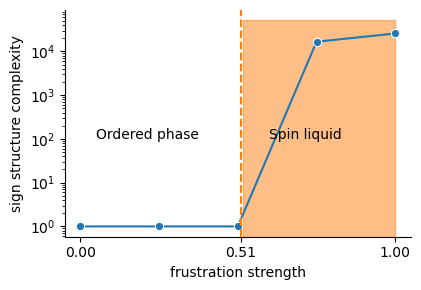

In [11]:
df = pd.DataFrame(outputs)
g = sns.relplot(
    df.rename(columns={"J2": "frustration strength"}),
    x="frustration strength",
    y="complexity",
    kind="line",
    markers=["o"],
    style=1,
    legend=False,
    height=3,
    aspect=1.5,
).set(yscale="log")

# plot vertical line at x=0.51
ax = g.axes[0][0]
ax.axvline(0.51, color="C1", linestyle="dashed")
ax.text(0.05, 100, "Ordered phase")
ax.text(0.6, 100, "Spin liquid")
# add a major tick with label to horizontal axis at position 0.51,
# while keeping other ticks
ax.set_xticks([0.0, 0.51, 1])
ax.set_ylabel("sign structure complexity")
x = np.linspace(min(df["J2"]), max(df["J2"]), 100)
ax.fill_between(
    x,
    df["complexity"].min() - 100,
    df["complexity"].max() * 2,
    where=(x > 0.51),
    alpha=0.5,
    color="C1",
)

plt.savefig("fig/kagome-sign-structure-complexity.png", dpi=300)

In [3]:
df

NameError: name 'df' is not defined